# MACHINE LEARNING 2026 - FINAL PROJECT (Option 1)

Course 2025/26: *C. Sun*, *M. Pavan*, *P. Zanuttigh*  

**Group Members:**        
*`Tommaso Dambi ID:2141118`*         
*`Alessandro Costabile ID:2146702`*        
*`Carlo Toffoli ID:2144522`*

## Heart Disease Analysis Using Clustering and Classification
<center>
    <img src="data/dataset-cover.jpg" style = "width: 50%;">
</center>

The dataset labels are the following:

|   id| age   | sex | dataset | cp | trestbps | chol | fbs | restecg | thalch | exang | oldpeak |slope | ca | thal | num |
| :-: | :-:  |  :-: | :-: | :-:| :-: | :-: | :-: | :-: | :-: | :-: | :-: | :-: | :-: | :-: | :-: |
| 1  |  63   | Male | Cleveland | typical angina | 145 | 233 | TRUE | Iv hypertrophy | 150 | FALSE | 2.3 | downsloping | 0 | fixed defect | 0 |
| 2  | 67   | Male | Cleveland | asymptomatic | 160 | 286 | FALSE | Iv hypertrophy | 108 | TRUE | 1.5 | flat | 3 | normal | 1 |
| 3   | 67 | Male | Cleveland | asymptomatic | 120 | 229 | FALSE | Iv hypertrophy | 129 | TRUE | 2.6 | flat | 2 | reversable | 2 |
| 4   | 37| Male | Cleveland | non-anginal | 130 | 250 | FALSE | normal | 187 | FALSE | 3.5 | downsloping | 0 | normal | 3 |

Description of the features:
 - `cp`: chest pain type:
    1. typical angina
    2. atypical angina
    3. non-anginal pain
    4. asymptomatic
 - `trestbps`: resting blood pressure (in mm Hg on admission to the hospital)
 - `chol`: serum cholestoral [mg/dL]
 - `fbs`: fasting blood sugar (True if above 120 mg/dL)
 - `restecg`: resting electrocardiographic results
    1. having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
    2. showing probable or definite left ventricular hypertrophy by Estes' criteria
    3. normal
 - `thalch`: maximum heart rate achieved
 - `exang`: exercise induced angina
    1. yes
    2. no
 - `oldpeak`: ST depression induced by exercise relative to rest
 - `slope`: the slope of the peak exercise ST segment
    1. upsloping
    2. flat
    3. downsloping
 - `ca`: number of major vessels (0-3) colored by flouroscopy
 - `thal`: type of defect in blood flow towards heart
    1. fixed defect
    2. reversable
    3. normal
 - `num`: label - severity of the disease from 0 (not present) to 4 (max severity)

Some records lack of data of some features such as `trestbps`, `chol`, `fbs`, `thalch`, `exang`, `oldpeak`, `ca`. This has to be addressed, maybe with clustering?

# Documentation used
- [Numpy](https://numpy.org/doc/stable/reference/index.html#reference)
- [Pandas](https://pandas.pydata.org/docs/reference/index.html#api)
- [Scikit-learn](https://scikit-learn.org/stable/api/index.html)

# ⚠️ OCIO
Il dataset non è incluso per ovvi motivi nel repository github. Scaricalo, estrailo e mettilo nella cartella `/data`. Ricorda di aggiornare il nome del file!
Also: the jupyter server was launched from the upper dir of the project (tdc_fp/..). All the relative imports were done accordingly.

# CODE

## Imports

In [342]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tdc_fp.preproc import (
    load_dataset, split_dataset, filter_dataset, 
    encode_dataset, standardize, binarize
)
from seaborn import pairplot, heatmap
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, AgglomerativeClustering
from tdc_fp.supervised import algo_selection
from sklearn.decomposition import PCA
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score

ENC_ORDINAL = True
# ID = 2141118
# np.random.seed(ID)

## 1. Data Preprocessing
All the preprocessing helper functions are defined in `preproc.py`.
As many samples lack the significant `ca` feature we have decided to use just the Cleveland data which provides that feature in almost all the samples.

In [343]:
# Load dataset
# If during testing a column is not needed it may be added to the dropped columns here
csv_dataframe = load_dataset('tdc_fp/data/heart_disease_uci.csv', drop_columns=['id', 'thal'])

encoded_features = [1,2,3,7,11] # TODO: Update when dropping features!
if ENC_ORDINAL:
    # OrdinalEncoder code
    # dataset, value_map = encode_feature(csv_dataframe) # Old code - value map is list of list!
    enc = OrdinalEncoder().fit(csv_dataframe.to_numpy())
    value_map = [np.append(np.random.permutation(a[:-1]), a[-1]) if a[-1] is np.nan else np.random.permutation(a) if i in encoded_features else a for i, a in enumerate(enc.categories_)]
    dataset = OrdinalEncoder(categories=value_map).fit_transform(csv_dataframe.to_numpy())
    feature_names = csv_dataframe.columns
else:
    # OneHotEncoder code
    dataset, feature_names = encode_dataset(csv_dataframe, encoded_features) # OneHotEncoder

# Print the mapped array
print("Dataset is:")
print(dataset.dtype, dataset.shape)

# Deal with nan values BEFORE STANDARDIZATION (issue #2)

# First filter: keep only clean samples from Cleveland
# dataset_filtered = filter_dataset(dataset, lambda x: not np.isnan(x[1]).any() and x[1][2] == np.where(value_map[2] == "Cleveland"))
# dataset_filtered = filter_dataset(dataset.T, lambda x: x[0] not in (12,13)).T
dataset_filtered = filter_dataset(dataset, lambda x: not np.isnan(x[1]).any())
# Second filter: all the samples are from Cleveland, drop that column!
# column 2 is the dataset column
print("\nFiltered dataset is:")
print(dataset_filtered.dtype, dataset_filtered.shape)

X, Y = split_dataset(dataset_filtered)
print("\nX and Y shapes after filtering:")
print(X.shape, Y.shape)

# Comment this code if you're trying to do multiclass classification
Y = binarize(Y)

# A dataframe is useful for visualization
dataframe = pd.DataFrame(X)
dataframe["num"] = Y
dataframe.columns = feature_names

# Standardization
X = standardize(X)

# If you want to take a look to the correlation factor between the single features and the label:
# print(np.corrcoef(X.T[9], Y.ravel()))

print(f"\nUnique values of Y: {np.unique(Y)}")
print()
print(pd.DataFrame(X).describe().round(3))

[array([28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44,
       45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61,
       62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77],
      dtype=object), array(['Female', 'Male'], dtype=object), array(['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach'],
      dtype=object), array(['asymptomatic', 'atypical angina', 'non-anginal', 'typical angina'],
      dtype=object), array([0.0, 80.0, 92.0, 94.0, 95.0, 96.0, 98.0, 100.0, 101.0, 102.0,
       104.0, 105.0, 106.0, 108.0, 110.0, 112.0, 113.0, 114.0, 115.0,
       116.0, 117.0, 118.0, 120.0, 122.0, 123.0, 124.0, 125.0, 126.0,
       127.0, 128.0, 129.0, 130.0, 132.0, 134.0, 135.0, 136.0, 138.0,
       140.0, 142.0, 144.0, 145.0, 146.0, 148.0, 150.0, 152.0, 154.0,
       155.0, 156.0, 158.0, 160.0, 164.0, 165.0, 170.0, 172.0, 174.0,
       178.0, 180.0, 185.0, 190.0, 192.0, 200.0, nan], dtype=object), array([0.0, 85.0, 100.0, 117.0, 126.0, 129.0

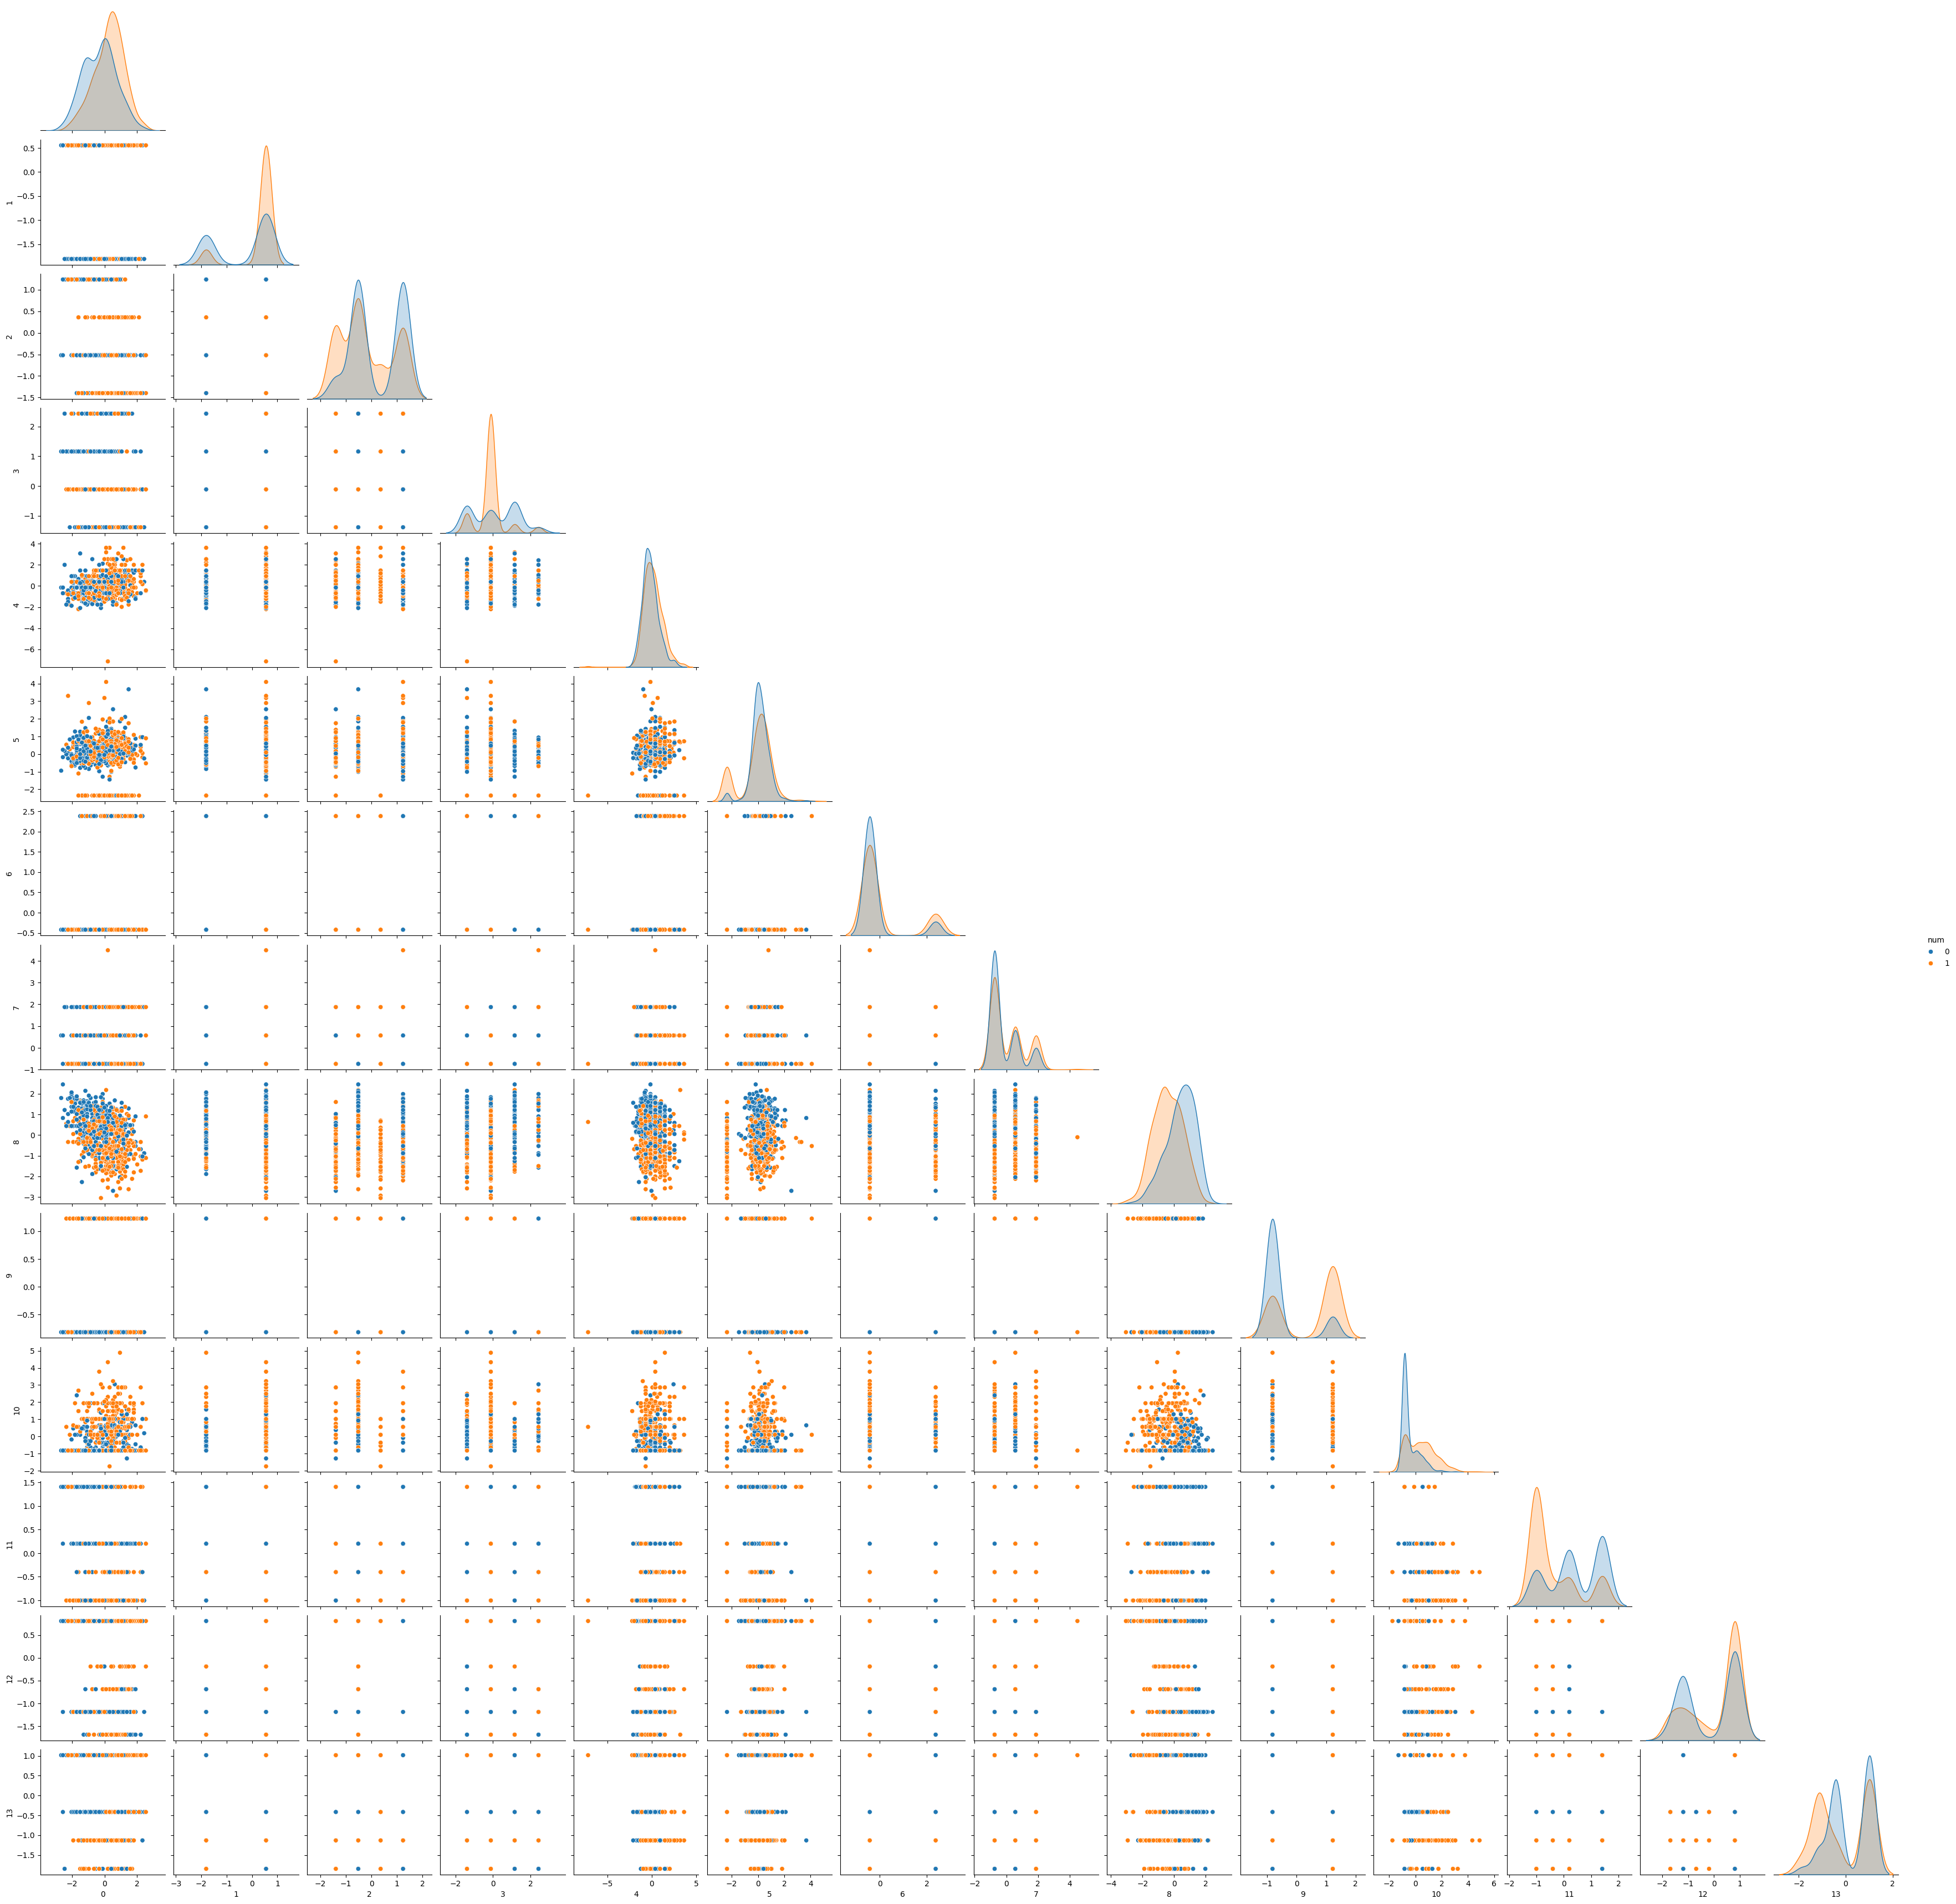

In [5]:
# print(feature_names)
import pandas as pd
from seaborn import pairplot
df = pd.DataFrame(X)
df['num'] = Y

pairplot(df, hue="num", corner=True)
# plt.savefig("pairplot_onehot.jpg")

# heatmap(data=dataframe.corr(), cmap="crest")
# plt.savefig("heatmap.jpg")

## 2. Clustering analysis

Va capita l'utilità di questa cosa: una volta trovati i cluster cosa ce ne facciamo? Vogliamo classificare in maniera unsupervised? boh
Ok, poi devo farlo prima del PCA? PCA serve solo a visualizzare i dati o posso anche comprendere se una componente in particolare ha la giusta combinazione di features che permette una classificazione lineare?

In [345]:
# Dataset split
permuted_indexes = np.random.permutation(X.shape[0])

X = X[permuted_indexes]
Y = Y[permuted_indexes].ravel()

# Splitting with stratification ensures consistency of the Y distribution between the train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=ID)
print("Distribution of patients in train set:", np.unique(y_train, return_counts=True)[1])
print("Distribution of patients in test set:", np.unique(y_test, return_counts=True)[1])

Distribution of patients in train set: [128 112]
Distribution of patients in test set: [33 28]


In [1]:
# For what concerns visualization, we need to decompose the data into at most 3 components
# (plus the labels which are represented by the color of the datapoints)

# Do clustering into two clusters
clustering = KMeans(2, n_init=10).fit(X)
# clustering = AgglomerativeClustering(2, linkage='ward').fit(X)

labels = clustering.labels_

print("Scores - also with inverted labels")
print(f"Accuracy: {round(accuracy_score(labels, Y)*100, 2)} | {round((1-accuracy_score(labels, Y))*100, 2)} %")
print(f"Precision: {round(precision_score(labels, Y)*100, 2)} | {round((1-precision_score(labels, Y))*100, 2)} %")
# print(f"Inertia: {clustering.inertia_}")

pca = PCA(n_components=3)
X_reduced = pca.fit_transform(X)

plot_clusters(X_reduced, (Y == labels).astype(int), "Correctly classified")
plot_clusters(X_reduced, labels, "Cluster labels")
plot_clusters(X_reduced, Y, "Dataset labels")

print("PCA weights:")
print(pca.components_[0])

NameError: name 'KMeans' is not defined

In [1]:
from sklearn.metrics import precision_score
from util import accuracy, plot_clusters, pca_decomposition
from preproc import preprocessing
from clustering import kmeans, _elbow

X, Y, col_names = preprocessing(ordinal = True, permute_map=True, permute_data=True, random_state = None)

labels, _, _ = kmeans(X)

print("Scores - also with inverted labels")
print(f"Accuracy: {round(accuracy(labels, Y)*100, 2)} | {round((1-accuracy(labels, Y))*100, 2)} %")
print(f"Precision: {round(precision_score(labels, Y)*100, 2)} | {round((1-precision_score(labels, Y))*100, 2)} %")

X_reduced, components = pca_decomposition(X)

# plot_clusters(X_reduced, (Y == labels).astype(int), "Correctly classified")
# plot_clusters(X_reduced, labels, "Cluster labels")
# plot_clusters(X_reduced, Y, "Dataset labels")

print("PCA weights:")
print(components[0])

# TODO: cambio in classificazione multiclasse, aumento il numero di cluster, trovo quali sono i cluster con maggiore rischio e trovo dei bounds nelle features
# Nell'aumentare il numero dei clusters lo faccio sopra al 4 in quanto con soli 4 ho i labels delle patologie

# _elbow(X, 50)

Dataset is float64 (741, 14)
Scores - also with inverted labels
Accuracy: 21.32 | 78.68 %
Precision: 22.4 | 77.6 %
PCA weights:
[-0.28909372  0.04627008  0.27775099  0.28024793 -0.12043435  0.0234291
 -0.07931207  0.23321851  0.11422829 -0.26785218 -0.33955687  0.46045653
  0.34986578  0.38515804]


## Clustering secondo Martina
Martina propone un clustering multiclasse.
Al variare del numero di cluster notare:
- I cluster a maggior rischio (quelli con il numero piu' elevato di malati pesati con il rischio, e normalizzati alla somma dei pesi)
- (min, max, mean) dei valori assunti dalle features in quei cluster

In [10]:
from clustering import algo_showcase, agglomerative, kmeans
from preproc import Preprocess

data = Preprocess(dropped=['dataset'], encoded_features=[1,2,6,10,11,12], permute_map=True, permute_data=True, multiclass=True)

for df in algo_showcase(data, range(4,20), kmeans, head=1):
    df = df.rename(columns={old:new for old, new in enumerate(['cluster n°', 'risk'] + data.feature_names.to_list())})
    df.set_index('cluster n°', inplace=True)
    display(df)



Number of clusters: 4


,risk,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
cluster n°,,,,,,,,,,,,,,
0,1.601,"(31.0, 77.0, 55.714)","(0.0, 1.0, 0.92)","(0.0, 3.0, 2.681)","(92.0, 200.0, 136.455)","(0.0, 404.0, 180.239)","(0.0, 0.0, 0.0)","(0.0, 2.0, 1.451)","(60.0, 160.0, 119.023)","(0.0, 1.0, 0.864)","(-1.0, 6.2, 1.611)","(0.0, 4.0, 0.465)","(0.0, 5.0, 4.225)","(0.0, 4.0, 2.592)"
2,1.337,"(43.0, 75.0, 58.99)","(0.0, 1.0, 0.846)","(0.0, 3.0, 2.058)","(101.0, 200.0, 140.529)","(0.0, 603.0, 230.038)","(1.0, 1.0, 1.0)","(0.0, 2.0, 1.096)","(69.0, 184.0, 134.192)","(0.0, 1.0, 0.481)","(0.0, 4.0, 1.094)","(0.0, 4.0, 1.337)","(0.0, 5.0, 3.5)","(0.0, 4.0, 2.346)"
3,0.676,"(29.0, 77.0, 53.311)","(0.0, 1.0, 0.612)","(0.0, 3.0, 1.676)","(94.0, 192.0, 129.731)","(0.0, 564.0, 248.119)","(0.0, 1.0, 0.005)","(0.0, 2.0, 1.059)","(97.0, 202.0, 155.516)","(0.0, 1.0, 0.205)","(0.0, 4.4, 0.796)","(0.0, 2.0, 1.123)","(0.0, 5.0, 1.091)","(0.0, 4.0, 1.603)"
1,0.278,"(28.0, 66.0, 47.171)","(0.0, 1.0, 0.727)","(0.0, 3.0, 1.766)","(0.0, 190.0, 128.229)","(0.0, 529.0, 227.039)","(0.0, 1.0, 0.029)","(0.0, 4.0, 1.751)","(80.0, 190.0, 143.615)","(0.0, 1.0, 0.083)","(-0.5, 3.0, 0.149)","(0.0, 4.0, 3.659)","(1.0, 5.0, 4.98)","(0.0, 4.0, 3.732)"




Number of clusters: 5


,risk,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
cluster n°,,,,,,,,,,,,,,
3,1.833,"(38.0, 75.0, 57.548)","(0.0, 1.0, 0.964)","(0.0, 3.0, 2.321)","(0.0, 200.0, 133.036)","(0.0, 223.0, 13.964)","(0.0, 1.0, 0.19)","(0.0, 2.0, 1.476)","(60.0, 180.0, 117.238)","(0.0, 1.0, 0.595)","(-1.0, 3.0, 0.779)","(0.0, 4.0, 0.952)","(1.0, 5.0, 4.952)","(0.0, 4.0, 1.988)"
1,1.785,"(35.0, 77.0, 57.531)","(0.0, 1.0, 0.746)","(0.0, 3.0, 2.746)","(100.0, 200.0, 135.6)","(100.0, 409.0, 254.338)","(0.0, 1.0, 0.154)","(0.0, 2.0, 0.831)","(71.0, 186.0, 132.438)","(0.0, 1.0, 0.762)","(0.0, 6.2, 1.762)","(0.0, 4.0, 0.508)","(0.0, 5.0, 1.562)","(0.0, 2.0, 1.123)"
2,1.253,"(31.0, 77.0, 55.363)","(0.0, 1.0, 0.87)","(0.0, 3.0, 2.685)","(92.0, 200.0, 139.0)","(117.0, 603.0, 258.123)","(0.0, 1.0, 0.24)","(0.0, 2.0, 1.575)","(69.0, 175.0, 123.541)","(0.0, 1.0, 0.849)","(0.0, 5.0, 1.691)","(0.0, 4.0, 0.582)","(1.0, 5.0, 4.973)","(1.0, 4.0, 3.87)"
4,0.374,"(29.0, 76.0, 52.326)","(0.0, 1.0, 0.642)","(0.0, 3.0, 1.219)","(94.0, 192.0, 128.973)","(126.0, 564.0, 242.316)","(0.0, 1.0, 0.144)","(0.0, 2.0, 1.139)","(96.0, 202.0, 159.845)","(0.0, 1.0, 0.048)","(0.0, 3.6, 0.571)","(0.0, 4.0, 1.374)","(0.0, 5.0, 1.139)","(0.0, 4.0, 1.674)"
0,0.237,"(28.0, 74.0, 47.247)","(0.0, 1.0, 0.732)","(0.0, 3.0, 1.763)","(98.0, 190.0, 129.706)","(0.0, 529.0, 236.907)","(0.0, 1.0, 0.067)","(0.0, 4.0, 1.747)","(80.0, 190.0, 143.371)","(0.0, 1.0, 0.072)","(0.0, 2.0, 0.071)","(0.0, 4.0, 3.845)","(1.0, 5.0, 4.979)","(0.0, 4.0, 3.716)"




Number of clusters: 6


...

,risk,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
cluster n°,,,,,,,,,,,,,,
15,2.375,"(50.0, 70.0, 60.75)","(0.0, 1.0, 0.625)","(1.0, 3.0, 2.875)","(114.0, 180.0, 148.812)","(164.0, 409.0, 279.688)","(0.0, 0.0, 0.0)","(0.0, 1.0, 0.125)","(109.0, 160.0, 139.25)","(0.0, 1.0, 0.312)","(1.9, 6.2, 3.287)","(0.0, 2.0, 0.562)","(0.0, 3.0, 1.938)","(0.0, 2.0, 1.0)"
11,1.973,"(35.0, 77.0, 56.027)","(0.0, 1.0, 0.973)","(1.0, 3.0, 2.865)","(100.0, 160.0, 127.676)","(166.0, 349.0, 242.378)","(0.0, 1.0, 0.081)","(0.0, 1.0, 0.027)","(96.0, 162.0, 126.703)","(0.0, 1.0, 0.973)","(0.0, 3.6, 1.586)","(0.0, 2.0, 0.541)","(0.0, 5.0, 1.162)","(0.0, 2.0, 1.297)"
16,1.922,"(38.0, 73.0, 57.562)","(0.0, 1.0, 0.984)","(0.0, 3.0, 2.266)","(105.0, 185.0, 134.25)","(0.0, 153.0, 2.391)","(0.0, 1.0, 0.047)","(0.0, 2.0, 1.484)","(60.0, 156.0, 113.016)","(0.0, 1.0, 0.672)","(-1.0, 3.0, 0.702)","(0.0, 4.0, 0.766)","(1.0, 5.0, 4.938)","(0.0, 4.0, 1.859)"
5,1.810,"(47.0, 70.0, 59.619)","(1.0, 1.0, 1.0)","(0.0, 3.0, 2.571)","(110.0, 160.0, 131.524)","(100.0, 353.0, 237.81)","(0.0, 0.0, 0.0)","(2.0, 2.0, 2.0)","(71.0, 145.0, 117.571)","(0.0, 1.0, 0.81)","(0.0, 5.6, 1.943)","(0.0, 2.0, 0.19)","(0.0, 3.0, 0.714)","(0.0, 2.0, 1.0)"
9,1.732,"(43.0, 75.0, 60.107)","(0.0, 1.0, 0.964)","(0.0, 3.0, 2.679)","(110.0, 190.0, 142.839)","(0.0, 603.0, 229.375)","(1.0, 1.0, 1.0)","(0.0, 2.0, 1.143)","(69.0, 161.0, 122.607)","(0.0, 1.0, 0.643)","(0.0, 4.0, 1.246)","(0.0, 4.0, 1.286)","(1.0, 5.0, 4.679)","(0.0, 4.0, 3.089)"
12,1.706,"(35.0, 67.0, 49.882)","(0.0, 1.0, 0.941)","(0.0, 3.0, 2.529)","(110.0, 140.0, 127.235)","(169.0, 318.0, 247.471)","(0.0, 0.0, 0.0)","(1.0, 2.0, 1.765)","(95.0, 182.0, 127.529)","(1.0, 1.0, 1.0)","(1.0, 4.2, 2.118)","(0.0, 2.0, 0.235)","(1.0, 5.0, 3.647)","(0.0, 2.0, 0.765)"
0,1.357,"(31.0, 77.0, 53.952)","(1.0, 1.0, 1.0)","(0.0, 3.0, 2.833)","(92.0, 200.0, 138.202)","(117.0, 404.0, 249.452)","(0.0, 0.0, 0.0)","(0.0, 2.0, 1.667)","(73.0, 160.0, 122.25)","(0.0, 1.0, 0.893)","(0.5, 5.0, 1.98)","(0.0, 4.0, 0.357)","(5.0, 5.0, 5.0)","(4.0, 4.0, 4.0)"
7,1.154,"(43.0, 71.0, 58.923)","(0.0, 0.0, 0.0)","(0.0, 3.0, 1.692)","(110.0, 200.0, 144.692)","(178.0, 417.0, 286.769)","(1.0, 1.0, 1.0)","(0.0, 2.0, 0.769)","(96.0, 170.0, 140.923)","(0.0, 1.0, 0.462)","(0.0, 4.0, 1.115)","(0.0, 4.0, 1.462)","(0.0, 5.0, 1.769)","(0.0, 2.0, 1.538)"
10,0.696,"(29.0, 70.0, 52.413)","(1.0, 1.0, 1.0)","(0.0, 3.0, 1.457)","(105.0, 192.0, 132.13)","(149.0, 321.0, 243.043)","(0.0, 0.0, 0.0)","(0.0, 0.0, 0.0)","(125.0, 202.0, 164.696)","(0.0, 1.0, 0.043)","(0.0, 3.2, 0.635)","(0.0, 2.0, 1.152)","(0.0, 5.0, 1.174)","(0.0, 2.0, 1.5)"




Number of clusters: 18


,risk,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
cluster n°,,,,,,,,,,,,,,
9,2.435,"(43.0, 70.0, 59.087)","(0.0, 1.0, 0.609)","(1.0, 3.0, 2.913)","(114.0, 200.0, 148.739)","(164.0, 409.0, 269.435)","(0.0, 1.0, 0.174)","(0.0, 2.0, 0.217)","(109.0, 160.0, 137.783)","(0.0, 1.0, 0.522)","(1.9, 6.2, 3.422)","(0.0, 2.0, 0.565)","(0.0, 5.0, 1.957)","(0.0, 2.0, 0.957)"
8,2.000,"(38.0, 70.0, 56.643)","(0.0, 1.0, 0.976)","(0.0, 3.0, 2.762)","(105.0, 200.0, 132.976)","(0.0, 153.0, 3.643)","(0.0, 1.0, 0.048)","(0.0, 2.0, 1.619)","(60.0, 156.0, 110.881)","(0.0, 1.0, 0.738)","(-1.0, 2.0, 0.51)","(0.0, 4.0, 0.643)","(5.0, 5.0, 5.0)","(0.0, 4.0, 1.095)"
5,1.857,"(35.0, 77.0, 56.057)","(1.0, 1.0, 1.0)","(0.0, 3.0, 2.771)","(100.0, 160.0, 126.371)","(167.0, 349.0, 246.686)","(0.0, 1.0, 0.057)","(0.0, 0.0, 0.0)","(96.0, 162.0, 126.629)","(0.0, 1.0, 0.971)","(0.0, 3.2, 1.446)","(0.0, 2.0, 0.543)","(0.0, 5.0, 1.229)","(0.0, 2.0, 1.286)"
12,1.808,"(43.0, 73.0, 59.423)","(0.0, 1.0, 0.962)","(0.0, 3.0, 1.192)","(116.0, 180.0, 137.731)","(0.0, 214.0, 8.231)","(0.0, 1.0, 0.077)","(0.0, 2.0, 1.308)","(72.0, 180.0, 120.731)","(0.0, 1.0, 0.577)","(-0.5, 3.0, 1.25)","(0.0, 4.0, 0.923)","(1.0, 5.0, 4.846)","(1.0, 4.0, 3.5)"
17,1.759,"(35.0, 70.0, 54.69)","(0.0, 1.0, 0.931)","(2.0, 3.0, 2.966)","(110.0, 160.0, 129.793)","(100.0, 353.0, 239.207)","(0.0, 0.0, 0.0)","(1.0, 2.0, 1.931)","(71.0, 173.0, 120.483)","(0.0, 1.0, 0.897)","(0.0, 4.2, 1.852)","(0.0, 2.0, 0.207)","(0.0, 5.0, 1.448)","(0.0, 2.0, 0.828)"
0,1.680,"(40.0, 75.0, 60.4)","(0.0, 1.0, 0.92)","(0.0, 3.0, 2.64)","(108.0, 178.0, 139.36)","(0.0, 330.0, 192.08)","(1.0, 1.0, 1.0)","(0.0, 2.0, 1.2)","(84.0, 165.0, 133.24)","(0.0, 1.0, 0.4)","(0.0, 3.4, 0.62)","(0.0, 4.0, 2.08)","(2.0, 5.0, 4.16)","(0.0, 2.0, 0.8)"
10,1.627,"(44.0, 77.0, 57.941)","(0.0, 1.0, 0.961)","(2.0, 3.0, 2.922)","(124.0, 200.0, 147.843)","(164.0, 404.0, 257.471)","(0.0, 0.0, 0.0)","(0.0, 2.0, 1.549)","(82.0, 158.0, 121.843)","(1.0, 1.0, 1.0)","(0.5, 5.0, 2.261)","(0.0, 4.0, 0.431)","(5.0, 5.0, 5.0)","(1.0, 4.0, 3.882)"
6,1.561,"(46.0, 75.0, 59.854)","(0.0, 1.0, 0.927)","(0.0, 3.0, 2.537)","(110.0, 190.0, 143.927)","(0.0, 603.0, 253.683)","(1.0, 1.0, 1.0)","(0.0, 2.0, 1.317)","(69.0, 175.0, 123.244)","(0.0, 1.0, 0.683)","(0.0, 4.0, 1.427)","(0.0, 4.0, 1.024)","(1.0, 5.0, 4.829)","(1.0, 4.0, 3.878)"
3,1.273,"(37.0, 70.0, 55.682)","(1.0, 1.0, 1.0)","(0.0, 1.0, 0.091)","(100.0, 160.0, 131.182)","(160.0, 335.0, 244.409)","(0.0, 0.0, 0.0)","(0.0, 2.0, 1.636)","(112.0, 187.0, 151.227)","(0.0, 1.0, 0.318)","(0.0, 3.8, 2.023)","(0.0, 4.0, 0.773)","(0.0, 5.0, 1.818)","(0.0, 4.0, 1.5)"




Number of clusters: 19


,risk,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
cluster n°,,,,,,,,,,,,,,
15,2.385,"(43.0, 70.0, 59.462)","(0.0, 1.0, 0.654)","(0.0, 3.0, 2.577)","(114.0, 200.0, 147.423)","(164.0, 409.0, 263.846)","(0.0, 1.0, 0.154)","(0.0, 2.0, 0.192)","(109.0, 173.0, 140.115)","(0.0, 1.0, 0.462)","(1.9, 6.2, 3.342)","(0.0, 2.0, 0.577)","(0.0, 5.0, 1.962)","(0.0, 2.0, 1.0)"
13,2.024,"(42.0, 70.0, 57.805)","(0.0, 1.0, 0.976)","(2.0, 3.0, 2.976)","(110.0, 200.0, 136.293)","(0.0, 153.0, 3.732)","(0.0, 0.0, 0.0)","(0.0, 2.0, 1.537)","(60.0, 156.0, 111.366)","(0.0, 1.0, 0.805)","(-1.0, 2.0, 0.632)","(0.0, 4.0, 0.756)","(1.0, 5.0, 4.902)","(0.0, 4.0, 1.366)"
11,1.880,"(48.0, 75.0, 60.8)","(0.0, 1.0, 0.88)","(1.0, 3.0, 2.84)","(122.0, 190.0, 151.32)","(202.0, 603.0, 295.08)","(1.0, 1.0, 1.0)","(0.0, 2.0, 1.48)","(69.0, 165.0, 123.68)","(0.0, 1.0, 0.84)","(0.0, 4.0, 1.776)","(0.0, 4.0, 0.56)","(2.0, 5.0, 4.8)","(1.0, 4.0, 3.68)"
14,1.865,"(40.0, 77.0, 57.27)","(1.0, 1.0, 1.0)","(0.0, 3.0, 2.784)","(100.0, 160.0, 126.405)","(167.0, 349.0, 249.676)","(0.0, 1.0, 0.081)","(0.0, 0.0, 0.0)","(96.0, 162.0, 127.189)","(0.0, 1.0, 0.919)","(0.0, 3.2, 1.465)","(0.0, 2.0, 0.514)","(0.0, 5.0, 1.216)","(0.0, 2.0, 1.297)"
16,1.765,"(38.0, 73.0, 56.824)","(0.0, 1.0, 0.941)","(0.0, 1.0, 0.118)","(105.0, 180.0, 137.353)","(0.0, 0.0, 0.0)","(0.0, 0.0, 0.0)","(0.0, 2.0, 1.294)","(72.0, 180.0, 118.176)","(0.0, 1.0, 0.529)","(-0.5, 3.0, 0.882)","(0.0, 4.0, 0.882)","(5.0, 5.0, 5.0)","(1.0, 4.0, 2.706)"
7,1.729,"(47.0, 77.0, 59.771)","(0.0, 1.0, 0.979)","(0.0, 3.0, 2.896)","(110.0, 200.0, 144.375)","(0.0, 388.0, 238.875)","(0.0, 0.0, 0.0)","(0.0, 2.0, 1.479)","(82.0, 158.0, 122.062)","(1.0, 1.0, 1.0)","(0.5, 5.0, 2.283)","(0.0, 4.0, 0.479)","(5.0, 5.0, 5.0)","(1.0, 4.0, 3.938)"
8,1.684,"(51.0, 70.0, 60.789)","(1.0, 1.0, 1.0)","(0.0, 3.0, 2.474)","(110.0, 160.0, 129.158)","(0.0, 230.0, 96.789)","(1.0, 1.0, 1.0)","(0.0, 2.0, 1.421)","(98.0, 161.0, 131.947)","(0.0, 1.0, 0.474)","(0.0, 3.4, 1.453)","(0.0, 2.0, 0.211)","(1.0, 5.0, 4.579)","(0.0, 4.0, 2.737)"
6,1.396,"(35.0, 71.0, 56.521)","(0.0, 1.0, 0.688)","(0.0, 3.0, 2.875)","(108.0, 180.0, 134.25)","(100.0, 393.0, 249.062)","(0.0, 0.0, 0.0)","(1.0, 2.0, 1.958)","(71.0, 173.0, 129.583)","(0.0, 1.0, 0.854)","(0.0, 4.2, 1.454)","(0.0, 2.0, 0.375)","(0.0, 5.0, 1.542)","(0.0, 2.0, 1.042)"
12,1.120,"(40.0, 75.0, 57.36)","(0.0, 1.0, 0.88)","(0.0, 3.0, 2.32)","(106.0, 180.0, 138.8)","(0.0, 333.0, 224.6)","(1.0, 1.0, 1.0)","(0.0, 2.0, 1.08)","(84.0, 165.0, 120.36)","(0.0, 1.0, 0.36)","(0.0, 1.0, 0.116)","(0.0, 4.0, 3.52)","(3.0, 5.0, 4.84)","(0.0, 4.0, 2.16)"


## 3. Supervised Learning

In [339]:
# # TODO: Riordinare

# # Call the algorithm selection function
# y_pred, y_score = algo_selection(X_train, X_test, y_train, y_test, ID)
# # The precision is the ratio tp / (tp + fp) where tp is the number of true positives and fp the number of false positives.
# # - Precision: di quelli che ho pedetto malati, quanti lo sono davvero
# # - Recall: dei malati veri, quanti ne ho beccati
# # - F1: media di precision e recall
# print("Test set results: ",
#     "\nAccurancy: ", round(100*np.sum(y_test == y_pred) / len(y_test), 3),
#     "\nPrecision: ", round(100*np.dot(y_test, y_pred) / np.sum(y_pred), 3),
#     "\nRecall: ", round(recall_score(y_test, y_pred), 3))